# P2.2 · Dot products

**Maths fundamentals for transformers · Tiny Transformer**

Attention must turn a query and a key into a comparable numerical score.

**You will be able to:** A dot product multiplies corresponding entries, then adds the contributions into one scalar.

This notebook runs independently in Jupyter or Google Colab on a CPU. Download it from the course, then use **Colab → File → Upload notebook**. Public publication target: https://github.com/gkiri/tiny_repo. All required numerical examples are included.

The model connection uses the same **9,417-parameter transformer** as Unit 1: 65 characters, 32 positions, 28 features, two heads, learned position embeddings, LayerNorm and GELU.

In [1]:
#@title Setup: CPU, local Jupyter or Google Colab { display-mode: "form" }
# This notebook is self-contained. No account, secret, repository clone or GPU is required.
import sys, math, json, base64, zlib, hashlib
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(7)
torch.set_num_threads(1)
plt.rcParams.update({"figure.figsize": (7, 3), "figure.dpi": 100, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": .18})
print("Ready on CPU · PyTorch", torch.__version__)
print("All example data is included in this notebook.")

Ready on CPU · PyTorch 2.10.0+cpu
All example data is included in this notebook.


## Predict first

How do two vectors make one score?

Write down your prediction before running the calculation.

Keep x = [2, 0, 1]. Change the last entry of w from −1 to 2. What is the new dot product?

## Work the numbers

1. Line up x = [2, 0, 1] and w = [1, 3, −1]

2. Multiply pairs: [2, 0, −1]

3. Accumulate: 2 + 0 − 1 = 1

4. Double x: score 2; direction alone does not set the score

$$\mathbf{x}\cdot\mathbf{w}=\sum_i x_iw_i=2(1)+0(3)+1(-1)=1$$

These small numbers are **Illustrative**. Each symbol names a quantity already shown above.

In [2]:
#@title Explicit teaching functions (expand to inspect) { display-mode: "form" }
"""P2's explicit calculations. Each function is checked against an independent PyTorch operation.

Rows use the final axis for features. Linear weights use PyTorch's [out, in] convention.
These readable implementations teach the operations; the reference model remains unchanged.
"""
import math
import torch


def dot(x, y):
    if x.shape != y.shape or x.ndim != 1:
        raise ValueError("dot needs two vectors of the same length")
    return (x * y).sum()


def linear(x, weight, bias):
    return x @ weight.transpose(-2, -1) + bias


def embeddings(ids, token_table, position_table):
    positions = torch.arange(ids.shape[-1], device=ids.device)
    if ids.shape[-1] > position_table.shape[0]:
        raise ValueError("the position table is shorter than the input")
    return token_table[ids] + position_table[positions]


def layernorm(x, gamma, beta, eps=1e-5):
    mean = x.mean(dim=-1, keepdim=True)
    variance = ((x - mean) ** 2).mean(dim=-1, keepdim=True)
    return (x - mean) / torch.sqrt(variance + eps) * gamma + beta


def softmax(scores, temperature=1.0):
    if temperature <= 0 or not math.isfinite(temperature):
        raise ValueError("temperature must be finite and positive")
    if torch.isnan(scores).any() or torch.isposinf(scores).any() or torch.isneginf(scores).all(dim=-1).any():
        raise ValueError("each score row needs a finite entry, with no NaN or positive infinity")
    scaled = scores / temperature
    shifted = scaled - scaled.max(dim=-1, keepdim=True).values
    positive = torch.exp(shifted)
    return positive / positive.sum(dim=-1, keepdim=True)


def attention(q, k, v):
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.shape[-1])
    allowed = torch.ones(scores.shape[-2:], dtype=torch.bool, device=q.device).tril()
    masked = scores.masked_fill(~allowed, float("-inf"))
    shares = softmax(masked)
    return shares @ v, shares, masked


def gelu(x):
    cdf = 0.5 * (1 + torch.erf(x / math.sqrt(2)))
    return x * cdf


def residual(x, update):
    if x.shape != update.shape:
        raise ValueError("a residual update must have the same shape as its input")
    return x + update


def cross_entropy(logits, targets):
    log_prob = logits - torch.logsumexp(logits, dim=-1, keepdim=True)
    correct = log_prob.gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    return -correct.mean()


def tiny_loss(w):
    """One adjustable logit: target 0, logits [2*w, 1, 0]."""
    z = torch.stack((2 * w, torch.ones_like(w), torch.zeros_like(w)))
    return cross_entropy(z.unsqueeze(0), torch.tensor([0], device=w.device))


def finite_difference(f, x, step=1e-5):
    return (f(x + step) - f(x - step)) / (2 * step)


def adamw_step(parameter, gradient, first, second, step, lr=0.003,
               betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01):
    """One AdamW update, including moment bias correction and decoupled weight decay."""
    beta1, beta2 = betas
    first = beta1 * first + (1 - beta1) * gradient
    second = beta2 * second + (1 - beta2) * gradient.square()
    first_hat = first / (1 - beta1 ** step)
    second_hat = second / (1 - beta2 ** step)
    parameter = parameter * (1 - lr * weight_decay) - lr * first_hat / (second_hat.sqrt() + eps)
    return parameter, first, second

print("Explicit functions loaded; each is independently tested against PyTorch.")

Explicit functions loaded; each is independently tested against PyTorch.


## Implement and verify

Read each line, predict its output, then run it. The explicit calculation and the PyTorch operation should agree.

In [3]:
x = torch.tensor([2., 0., 1.])
w = torch.tensor([1., 3., -1.])
products = x * w
print("contributions", products.tolist())
print("sum", products.sum().item(), "torch.dot", torch.dot(x, w).item())
print("double x", torch.dot(2 * x, w).item())
assert torch.dot(x, w).item() == 1.

contributions [2.0, 0.0, -1.0]
sum 1.0 torch.dot 1.0
double x 2.0


## See it and change one thing

The plot is generated by the code. Change one input and predict how the picture will change before running it again.

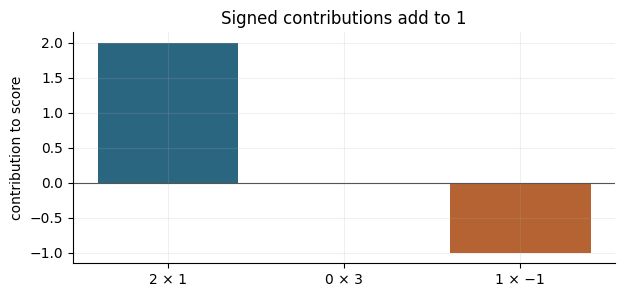

scale → score [(-2.0, -2.0), (-1.5, -1.5), (-1.0, -1.0), (-0.5, -0.5), (0.0, 0.0), (0.5, 0.5), (1.0, 1.0), (1.5, 1.5), (2.0, 2.0)]


In [4]:
x = np.array([2., 0., 1.]); w = np.array([1., 3., -1.])
plt.bar(range(3), x*w, color=["#2b6680", "#999999", "#b56332"])
plt.axhline(0, color="#555", lw=.8); plt.xticks(range(3), ["2 × 1", "0 × 3", "1 × −1"])
plt.ylabel("contribution to score"); plt.title("Signed contributions add to 1"); plt.show()
scales = torch.linspace(-2, 2, 9)
print("scale → score", [(float(s), float(torch.dot(s*torch.tensor(x), torch.tensor(w)))) for s in scales])

## Find it in the transformer

The following values were exported at full precision from the pinned Unit 1 checkpoint. Crops are for display; complete vectors are used in calculations.

Recorded input: `You taught me language; and my p`.

Reference lesson: **inside-attention**.

In [5]:
#@title Recorded model fixture (included; no download) { display-mode: "form" }
recorded = json.loads('{"query":[-0.9162237048149109,-0.1555691957473755,1.2177972793579102,5.3362226486206055,-0.1847497969865799,-1.6498217582702637,-2.07192063331604,3.959083080291748,-0.581139087677002,-1.1996207237243652,-1.2341582775115967,-4.258447170257568,3.127192735671997,-0.5446478724479675],"key":[-3.9904062747955322,-3.4468350410461426,-0.4884034991264343,4.63117790222168,-0.3908814787864685,-5.087323188781738,1.1242473125457764,4.449979305267334,-4.62955904006958,1.146024465560913,-3.1587166786193848,-5.040908336639404,5.774126052856445,-1.3250038623809814],"dot":97.52330017089844,"dot_products":[3.656104803085327,0.5362213850021362,-0.594776451587677,24.712995529174805,0.07221527397632599,8.393176078796387,-2.3293511867523193,17.61783790588379,2.690417766571045,-1.3747947216033936,3.8983564376831055,21.466442108154297,18.056804656982422,0.7216605544090271]}')
print("Recorded: prompter-r1; input: You taught me language; and my p")

Recorded: prompter-r1; input: You taught me language; and my p


In [6]:
q=torch.tensor(recorded["query"]); k=torch.tensor(recorded["key"]); print("14 contributions",(q*k).tolist()); print("dot",torch.dot(q,k).item()); assert abs(torch.dot(q,k).item()-recorded["dot"])<1e-5

14 contributions [3.656104803085327, 0.5362213850021362, -0.594776451587677, 24.712995529174805, 0.07221527397632599, 8.393176078796387, -2.3293511867523193, 17.61783790588379, 2.690417766571045, -1.3747947216033936, 3.8983564376831055, 21.466442108154297, 18.056804656982422, 0.7216605544090271]
dot 97.52330780029297


## A common trap

A dot product depends on length as well as direction. It is a score, not a probability or proof of semantic similarity.

### ✋ Your turn

Keep x = [2, 0, 1]. Change the last entry of w from −1 to 2. What is the new dot product?

In [7]:
answer = None  # TODO: make a prediction, then enter your answer

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert abs(float(answer) - 4) < 1e-6, 'Revisit the worked calculation above.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [8]:
#@title Show a solution { display-mode: "form" }
answer = 4.

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert abs(float(answer) - 4) < 1e-6, 'Revisit the worked calculation above.'
    print("✓ right:", answer)

✓ right: 4.0


## Connect the dots

A dot product multiplies corresponding entries, then adds the contributions into one scalar.

Next: matrices and learned linear layers.

To explain this operation to someone else, name its inputs, calculate one output, give its PyTorch equivalent, and point to its place in the transformer.